# 导库验证
首次导入库后做验证

In [1]:
import torch
import torch.nn as nn

In [2]:
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())          # Windows / Linux NVIDIA 期望 True
print("MPS Available:", torch.backends.mps.is_available())   # Mac M 系列期望 True

PyTorch Version: 2.13.0+cu130
CUDA Available: True
MPS Available: False


# 建立张量

In [3]:
# 建立张量
x = torch.tensor([[1.0]])
t = torch.tensor([[0.0]])

# 建立网络

In [4]:
# 建立网络
model = nn.Sequential(
	nn.Linear(1, 1, bias = False), # w1
	nn.ReLU(),
	nn.Linear(1, 1, bias = False), # w2
	nn.ReLU(),
	nn.Linear(1, 1, bias = False), # w3
)

# 初始化权重

In [10]:
# 初始化权重
with torch.no_grad():
	model[0].weight.fill_(2.0)
	model[2].weight.fill_(3.0)
	model[4].weight.fill_(-1.0)

# 配置损失函数及优化器

In [6]:
# 损失函数 MSE
criterion = nn.MSELoss()
# 优化器 随机梯度下降 SGD
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01) # 学习率 0.01

# 配置流程完成迭代

In [11]:
# 损失值的记录容器
loss_history = [] # idea by WangSen679

# 训练 100 轮
for epoch in range(100):
	loss = criterion(model(x), t)	# 前向传播 + 计算损失
	optimizer.zero_grad()					# 清空上一轮余留的梯度
	loss.backward()								# 反向传播自动计算梯度
	optimizer.step()							# 梯度下降更新权重
	loss_history.append(loss.item())
	if epoch % 10 == 0:
		print(f"Epoch {epoch+1:3d} | 预测值: {model(x).item():7.4f} | 损失: {loss.item():.4f}")

Epoch   1 | 预测值: -1.2674 | 损失: 36.0000
Epoch  11 | 预测值: -0.0084 | 损失: 0.0002
Epoch  21 | 预测值: -0.0001 | 损失: 0.0000
Epoch  31 | 预测值: -0.0000 | 损失: 0.0000
Epoch  41 | 预测值: -0.0000 | 损失: 0.0000
Epoch  51 | 预测值: -0.0000 | 损失: 0.0000
Epoch  61 | 预测值: -0.0000 | 损失: 0.0000
Epoch  71 | 预测值: -0.0000 | 损失: 0.0000
Epoch  81 | 预测值: -0.0000 | 损失: 0.0000
Epoch  91 | 预测值: -0.0000 | 损失: 0.0000


> 由于 PyTorch 的 nn.MSELoss() 默认是 $(y - t)^2$ (不带 $\cfrac{1}{2}$ 系数)  
> 因此第 1 轮损失为 36 而非推演的 18  
> 梯度也会相应大一倍，但不影响最终收敛结果

# 损失可视化
这部分的代码基于 [WangSen679:backprop-visualization](https://github.com/WangSen679/DL_qx2io/tree/backprop-visualization), 谢谢你的支持.  
更多详情可见 [Pull Request #1](https://github.com/NothingForID/Deep_Learning/pull/1).  

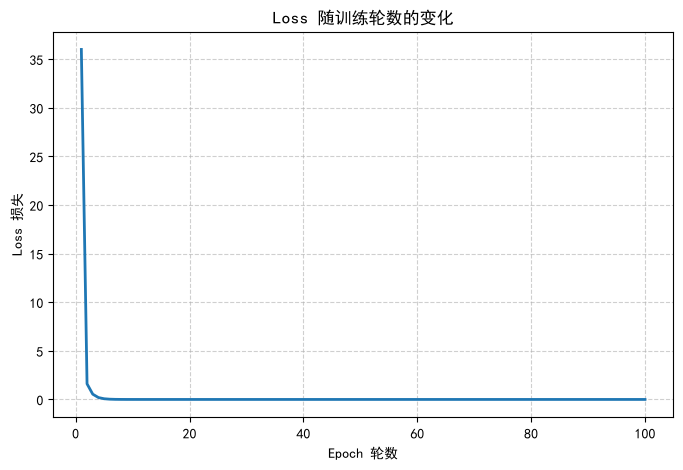

In [13]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize = (8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, color='tab:blue', linewidth=2)

plt.xlabel('Epoch 轮数')
plt.ylabel('Loss 损失')
plt.title('Loss 随训练轮数的变化')
plt.grid(True, linestyle='--', alpha = 0.6)
plt.show()
